# Real Data Performance

This notebook compares the performance of the EM approach to LOOCV approach using real-world datasets.

## Preview Experiment

In [ ]:
import numpy as np
import pandas as pd

from fastridge import RidgeEM, RidgeLOOCV
from experiments import Experiment
from problems import EmpiricalDataProblem, OneHotEncodeCategories, PolynomialExpansion, NEURIPS2023_TRAIN_SIZES

_OHE = (OneHotEncodeCategories(),)

problems = [
    EmpiricalDataProblem('abalone',    'Rings',                         x_transforms=_OHE, zero_variance_filter=True),
    EmpiricalDataProblem('airfoil',    'scaled-sound-pressure',                            zero_variance_filter=True),
    EmpiricalDataProblem('concrete',   'Concrete compressive strength',                    zero_variance_filter=True),
    EmpiricalDataProblem('diabetes',   'target',                                           zero_variance_filter=True),
    EmpiricalDataProblem('eye',        'y',                                                zero_variance_filter=True),
    EmpiricalDataProblem('forest',     'area',                          x_transforms=_OHE, zero_variance_filter=True),
    EmpiricalDataProblem('student',    ('G1', 'G2', 'G3'),              x_transforms=_OHE, zero_variance_filter=True),
    EmpiricalDataProblem('yacht',      'Residuary_resistance',                             zero_variance_filter=True),
    EmpiricalDataProblem('automobile', 'price', nan_policy='drop_rows', x_transforms=_OHE, zero_variance_filter=True),
]

estimators = {
    'EM':     RidgeEM(),
    'CV_fix': RidgeLOOCV(alphas=np.logspace(-10, 10, 100, endpoint=True, base=10)),
    'CV_glm': RidgeLOOCV(alphas=100),
}

exp = Experiment(
    problems, list(estimators.values()),
    reps=10, ns=[[NEURIPS2023_TRAIN_SIZES[p.dataset]] for p in problems],
    seed=123,
    est_names=list(estimators.keys())).run(ignore_cache=True)
print()

In [ ]:
def stat_mean(exp, stat_name, est_name, problem_idx):
    j = exp.est_names.index(est_name)
    return np.nanmean(getattr(exp, stat_name + '_')[:, problem_idx, 0, j])

rows = []
for i, problem in enumerate(exp.problems):
    em_time = stat_mean(exp, 'fitting_time', 'EM', i)
    cv_time = (stat_mean(exp, 'fitting_time', 'CV_glm', i)
               + stat_mean(exp, 'fitting_time', 'CV_fix', i)) / 2
    row = {'dataset': problem.dataset, 'target': ', '.join(problem.target) if isinstance(problem.target, tuple) else problem.target}
    row.update({est: stat_mean(exp, 'prediction_r2', est, i) for est in exp.est_names})
    row['Speed-Up'] = cv_time / em_time
    row['p']        = stat_mean(exp, 'number_of_features', 'EM', i)
    row['n_train']  = int(exp.ns[i, 0])
    row['n:p']      = int(exp.ns[i, 0]) / stat_mean(exp, 'number_of_features', 'EM', i)
    rows.append(row)
pd.DataFrame(rows).sort_values('n_train', ascending=False).round(2)

In [ ]:
problems_d2 = [
    EmpiricalDataProblem('abalone',    'Rings',                         x_transforms=_OHE + (PolynomialExpansion(2),),                         zero_variance_filter=True),
    EmpiricalDataProblem('airfoil',    'scaled-sound-pressure',         x_transforms=(PolynomialExpansion(2),),                                 zero_variance_filter=True),
    EmpiricalDataProblem('concrete',   'Concrete compressive strength', x_transforms=(PolynomialExpansion(2),),                                 zero_variance_filter=True),
    EmpiricalDataProblem('diabetes',   'target',                        x_transforms=(PolynomialExpansion(2),),                                 zero_variance_filter=True),
    EmpiricalDataProblem('eye',        'y',                             x_transforms=(PolynomialExpansion(2),),                                 zero_variance_filter=True),
    EmpiricalDataProblem('forest',     'area',                          x_transforms=_OHE + (PolynomialExpansion(2),),                         zero_variance_filter=True),
    EmpiricalDataProblem('student',    ('G1', 'G2', 'G3'),              x_transforms=_OHE + (PolynomialExpansion(2),),                         zero_variance_filter=True),
    EmpiricalDataProblem('yacht',      'Residuary_resistance',          x_transforms=(PolynomialExpansion(2),),                                 zero_variance_filter=True),
    EmpiricalDataProblem('automobile', 'price', nan_policy='drop_rows', x_transforms=_OHE + (PolynomialExpansion(2),),                         zero_variance_filter=True),
]

In [4]:
exp_d2 = Experiment(
    problems_d2, list(estimators.values()),
    reps=10, ns=[[NEURIPS2023_TRAIN_SIZES[p.dataset]] for p in problems_d2],
    seed=123,
    est_names=list(estimators.keys())).run(ignore_cache=True)
print()

abalone ..............................
airfoil ..............................
concrete ..............................
diabetes ..............................
eye ..............................
forest ..............................
student ..............................
yacht ..............................
automobile ..............................



In [ ]:
rows_d2 = []
for i, problem in enumerate(exp_d2.problems):
    em_time = stat_mean(exp_d2, 'fitting_time', 'EM', i)
    cv_time = (stat_mean(exp_d2, 'fitting_time', 'CV_glm', i)
               + stat_mean(exp_d2, 'fitting_time', 'CV_fix', i)) / 2
    row = {'dataset': problem.dataset, 'target': ', '.join(problem.target) if isinstance(problem.target, tuple) else problem.target}
    row.update({est: stat_mean(exp_d2, 'prediction_r2', est, i) for est in exp_d2.est_names})
    row['Speed-Up'] = cv_time / em_time
    row['p']        = stat_mean(exp_d2, 'number_of_features', 'EM', i)
    row['n_train']  = int(exp_d2.ns[i, 0])
    row['n:p']      = int(exp_d2.ns[i, 0]) / stat_mean(exp_d2, 'number_of_features', 'EM', i)
    rows_d2.append(row)
pd.DataFrame(rows_d2).sort_values('n_train', ascending=False).round(2)

In [ ]:
problems_d3 = [
    EmpiricalDataProblem('abalone',    'Rings',                         x_transforms=_OHE + (PolynomialExpansion(3),),                         zero_variance_filter=True),
    EmpiricalDataProblem('airfoil',    'scaled-sound-pressure',         x_transforms=(PolynomialExpansion(3),),                                 zero_variance_filter=True),
    EmpiricalDataProblem('concrete',   'Concrete compressive strength', x_transforms=(PolynomialExpansion(3),),                                 zero_variance_filter=True),
    EmpiricalDataProblem('diabetes',   'target',                        x_transforms=(PolynomialExpansion(3),),                                 zero_variance_filter=True),
    # EmpiricalDataProblem('eye',        'y'),  # excluded in paper for d=3
    EmpiricalDataProblem('forest',     'area',                          x_transforms=_OHE + (PolynomialExpansion(3),),                         zero_variance_filter=True),
    EmpiricalDataProblem('student',    ('G1', 'G2', 'G3'),              x_transforms=_OHE + (PolynomialExpansion(3),),                         zero_variance_filter=True),
    EmpiricalDataProblem('yacht',      'Residuary_resistance',          x_transforms=(PolynomialExpansion(3),),                                 zero_variance_filter=True),
    EmpiricalDataProblem('automobile', 'price', nan_policy='drop_rows', x_transforms=_OHE + (PolynomialExpansion(3),),                         zero_variance_filter=True),
]

In [7]:
exp_d3 = Experiment(
    problems_d3, list(estimators.values()),
    reps=10, ns=[[NEURIPS2023_TRAIN_SIZES[p.dataset]] for p in problems_d3],
    seed=123,
    est_names=list(estimators.keys())).run(ignore_cache=True)
print()

abalone ..............................
airfoil ..............................
concrete ..............................
diabetes ..............................
forest ..............................
student ..............................
yacht ..............................
automobile ..............................



In [ ]:
rows_d3 = []
for i, problem in enumerate(exp_d3.problems):
    em_time = stat_mean(exp_d3, 'fitting_time', 'EM', i)
    cv_time = (stat_mean(exp_d3, 'fitting_time', 'CV_glm', i)
               + stat_mean(exp_d3, 'fitting_time', 'CV_fix', i)) / 2
    row = {'dataset': problem.dataset, 'target': ', '.join(problem.target) if isinstance(problem.target, tuple) else problem.target}
    row.update({est: stat_mean(exp_d3, 'prediction_r2', est, i) for est in exp_d3.est_names})
    row['Speed-Up'] = cv_time / em_time
    row['p']        = stat_mean(exp_d3, 'number_of_features', 'EM', i)
    row['n_train']  = int(exp_d3.ns[i, 0])
    row['n:p']      = int(exp_d3.ns[i, 0]) / stat_mean(exp_d3, 'number_of_features', 'EM', i)
    rows_d3.append(row)
pd.DataFrame(rows_d3).sort_values('n_train', ascending=False).round(2)

In [9]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from plotting import scatter_clipped, grid_with_colourbar

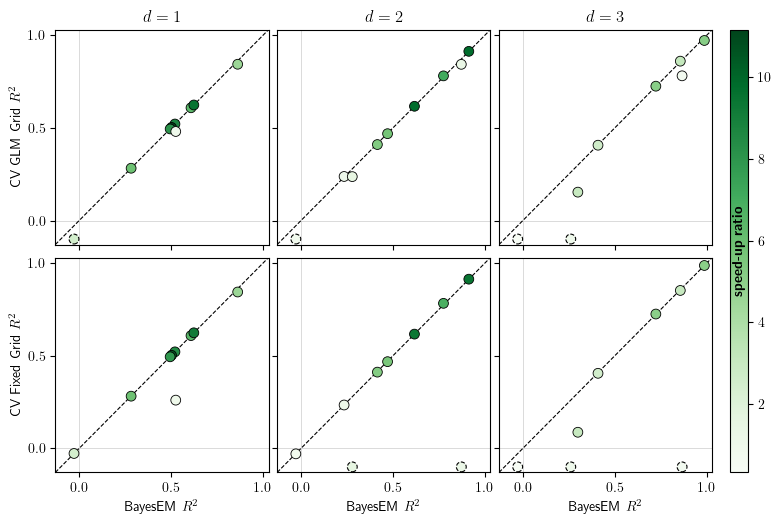

In [10]:
su_all = [np.nanmean(e.fitting_time_[:, i, 0, cv]) / np.nanmean(e.fitting_time_[:, i, 0, 0])
          for e in [exp, exp_d2, exp_d3] for cv in [1, 2] for i in range(len(e.problems))]
norm = mcolors.Normalize(vmin=min(su_all), vmax=max(su_all))

fig, axes = grid_with_colourbar(2, 3, norm, plt.cm.Greens,
                                y_labels=['CV GLM Grid $R^2$', 'CV Fixed Grid $R^2$'],
                                col_titles=['$d=1$', '$d=2$', '$d=3$'],
                                x_labels='BayesEM $R^2$', cbar_label=r'\textbf{speed-up ratio}')


for col, e in enumerate([exp, exp_d2, exp_d3]):
    for row, cv in enumerate([2, 1]):
        scatter_clipped(np.nanmean(e.prediction_r2_[:, :, 0, 0], axis=0),
                        np.nanmean(e.prediction_r2_[:, :, 0, cv], axis=0),
                        np.nanmean(e.fitting_time_[:, :, 0, cv], axis=0)
                        / np.nanmean(e.fitting_time_[:, :, 0, 0], axis=0),
                        norm, plt.cm.Greens, ax=axes[row, col])


## Full Experiment: Small and Moderately-sized Datasets

This experiment corresponds to Figure 3 of the appendix.

In [ ]:
problems_full = [
    EmpiricalDataProblem('abalone',          'Rings',                         x_transforms=_OHE,                         zero_variance_filter=True),
    EmpiricalDataProblem('airfoil',          'scaled-sound-pressure',                                                    zero_variance_filter=True),
    EmpiricalDataProblem('automobile',       'price',               nan_policy='drop_rows', x_transforms=_OHE,          zero_variance_filter=True),
    EmpiricalDataProblem('autompg',          'mpg',
                         drop=('car_name',), nan_policy='drop_rows',                                                      zero_variance_filter=True),
    EmpiricalDataProblem('crime',            'ViolentCrimesPerPop',
                         drop=('state', 'fold', 'communityname'),
                         nan_policy='drop_cols',                                                                          zero_variance_filter=True),
    EmpiricalDataProblem('ribo',             'y',                                                                         zero_variance_filter=True),
    EmpiricalDataProblem('eye',              'y',                                                                         zero_variance_filter=True),
    EmpiricalDataProblem('boston',           'medv',                                                                      zero_variance_filter=True),
    EmpiricalDataProblem('concrete',         'Concrete compressive strength',                                             zero_variance_filter=True),
    EmpiricalDataProblem('diabetes',         'target',                                                                    zero_variance_filter=True),
    EmpiricalDataProblem('facebook',         ('comment', 'like', 'share'),
                         drop=('Total Interactions',),
                         nan_policy='drop_rows',                    x_transforms=_OHE,                                   zero_variance_filter=True),
    EmpiricalDataProblem('forest',           'area',                          x_transforms=_OHE,                         zero_variance_filter=True),
    EmpiricalDataProblem('naval_propulsion', ('GT_compressor_decay', 'GT_turbine_decay'),                                zero_variance_filter=True),
    EmpiricalDataProblem('parkinsons',       ('motor_UPDRS', 'total_UPDRS'),                                             zero_variance_filter=True),
    EmpiricalDataProblem('real_estate',      'Y house price of unit area',                                               zero_variance_filter=True),
    EmpiricalDataProblem('student',          ('G1', 'G2', 'G3'),                               x_transforms=_OHE,        zero_variance_filter=True),
    EmpiricalDataProblem('yacht',            'Residuary_resistance',                                                      zero_variance_filter=True),
]

estimators_full = {
    'EM':     RidgeEM(),
    'CV_fix': RidgeLOOCV(alphas=np.logspace(-10, 10, 100, endpoint=True, base=10)),
    'CV_glm': RidgeLOOCV(alphas=100),
}

exp_full = Experiment(
    problems_full, list(estimators_full.values()),
    reps=100, ns=[[NEURIPS2023_TRAIN_SIZES[p.dataset]] for p in problems_full],
    seed=123,
    est_names=list(estimators_full.keys())).run()
print()

In [ ]:
rows_full = []
for i, problem in enumerate(exp_full.problems):
    em_time = stat_mean(exp_full, 'fitting_time', 'EM', i)
    cv_time = (stat_mean(exp_full, 'fitting_time', 'CV_glm', i)
               + stat_mean(exp_full, 'fitting_time', 'CV_fix', i)) / 2
    row = {'dataset': problem.dataset, 'target': ', '.join(problem.target) if isinstance(problem.target, tuple) else problem.target}
    row.update({est: stat_mean(exp_full, 'prediction_r2', est, i) for est in exp_full.est_names})
    row['Speed Up Ratio'] = cv_time / em_time
    row['p']              = stat_mean(exp_full, 'number_of_features', 'EM', i)
    row['n_train']        = int(exp_full.ns[i, 0])
    row['n:p']            = int(exp_full.ns[i, 0]) / stat_mean(exp_full, 'number_of_features', 'EM', i)
    rows_full.append(row)
pd.DataFrame(rows_full).sort_values('n_train', ascending=False).round(2)

In [ ]:
problems_full_d2 = [
    EmpiricalDataProblem('abalone',          'Rings',                         x_transforms=_OHE + (PolynomialExpansion(2),),                          zero_variance_filter=True),
    EmpiricalDataProblem('airfoil',          'scaled-sound-pressure',         x_transforms=(PolynomialExpansion(2),),                                  zero_variance_filter=True),
    EmpiricalDataProblem('automobile',       'price',               nan_policy='drop_rows', x_transforms=_OHE + (PolynomialExpansion(2),),              zero_variance_filter=True),
    EmpiricalDataProblem('autompg',          'mpg',
                         drop=('car_name',), nan_policy='drop_rows', x_transforms=(PolynomialExpansion(2),),                                           zero_variance_filter=True),
    EmpiricalDataProblem('crime',            'ViolentCrimesPerPop',
                         drop=('state', 'fold', 'communityname'),
                         nan_policy='drop_cols',                    x_transforms=(PolynomialExpansion(2),),                                            zero_variance_filter=True),
    # EmpiricalDataProblem('ribo',             'y'),  # memory exhaustion at d=2
    EmpiricalDataProblem('eye',              'y',                             x_transforms=(PolynomialExpansion(2),),                                  zero_variance_filter=True),
    EmpiricalDataProblem('boston',           'medv',                          x_transforms=(PolynomialExpansion(2),),                                  zero_variance_filter=True),
    EmpiricalDataProblem('concrete',         'Concrete compressive strength', x_transforms=(PolynomialExpansion(2),),                                  zero_variance_filter=True),
    EmpiricalDataProblem('diabetes',         'target',                        x_transforms=(PolynomialExpansion(2),),                                  zero_variance_filter=True),
    EmpiricalDataProblem('facebook',         ('comment', 'like', 'share'),
                         drop=('Total Interactions',),
                         nan_policy='drop_rows',                    x_transforms=_OHE + (PolynomialExpansion(2),),                                    zero_variance_filter=True),
    EmpiricalDataProblem('forest',           'area',                          x_transforms=_OHE + (PolynomialExpansion(2),),                           zero_variance_filter=True),
    EmpiricalDataProblem('naval_propulsion', ('GT_compressor_decay', 'GT_turbine_decay'), x_transforms=(PolynomialExpansion(2),),                      zero_variance_filter=True),
    EmpiricalDataProblem('parkinsons',       ('motor_UPDRS', 'total_UPDRS'),              x_transforms=(PolynomialExpansion(2),),                      zero_variance_filter=True),
    EmpiricalDataProblem('real_estate',      'Y house price of unit area',    x_transforms=(PolynomialExpansion(2),),                                  zero_variance_filter=True),
    EmpiricalDataProblem('student',          ('G1', 'G2', 'G3'),              x_transforms=_OHE + (PolynomialExpansion(2),),                          zero_variance_filter=True),
    EmpiricalDataProblem('yacht',            'Residuary_resistance',          x_transforms=(PolynomialExpansion(2),),                                  zero_variance_filter=True),
]

In [14]:
exp_full_d2 = Experiment(
    problems_full_d2, list(estimators_full.values()),
    reps=30, ns=[[NEURIPS2023_TRAIN_SIZES[p.dataset]] for p in problems_full_d2],
    seed=123,
    est_names=list(estimators_full.keys())).run()
print()

abalone .............................................................................

/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:341: UserWarning: FittingTime: only one computation stored; reliability unknown. Re-run with force_recompute=True to improve estimate.
  warnings.warn(msg)


.............
airfoil ..........................................................................................
automobile ..........................................................................................
autompg ..........................................................................................
crime ..........................................................................................
eye ..........................................................................................
boston ..........................................................................................
concrete ..........................................................................................
diabetes ..........................................................................................
facebook ..........................................................................................
forest .........................................................................................

In [ ]:
rows_full_d2 = []
for i, problem in enumerate(exp_full_d2.problems):
    em_time = stat_mean(exp_full_d2, 'fitting_time', 'EM', i)
    cv_time = (stat_mean(exp_full_d2, 'fitting_time', 'CV_glm', i)
               + stat_mean(exp_full_d2, 'fitting_time', 'CV_fix', i)) / 2
    row = {'dataset': problem.dataset, 'target': ', '.join(problem.target) if isinstance(problem.target, tuple) else problem.target}
    row.update({est: stat_mean(exp_full_d2, 'prediction_r2', est, i) for est in exp_full_d2.est_names})
    row['Speed Up Ratio'] = cv_time / em_time
    row['p']              = stat_mean(exp_full_d2, 'number_of_features', 'EM', i)
    row['n_train']        = int(exp_full_d2.ns[i, 0])
    row['n:p']            = int(exp_full_d2.ns[i, 0]) / stat_mean(exp_full_d2, 'number_of_features', 'EM', i)
    rows_full_d2.append(row)
pd.DataFrame(rows_full_d2).sort_values('n_train', ascending=False).round(2)

In [ ]:
problems_full_d3 = [
    EmpiricalDataProblem('abalone',          'Rings',                         x_transforms=_OHE + (PolynomialExpansion(3),),                          zero_variance_filter=True),
    EmpiricalDataProblem('airfoil',          'scaled-sound-pressure',         x_transforms=(PolynomialExpansion(3),),                                  zero_variance_filter=True),
    EmpiricalDataProblem('automobile',       'price',               nan_policy='drop_rows', x_transforms=_OHE + (PolynomialExpansion(3),),              zero_variance_filter=True),
    EmpiricalDataProblem('autompg',          'mpg',
                         drop=('car_name',), nan_policy='drop_rows', x_transforms=(PolynomialExpansion(3),),                                           zero_variance_filter=True),
    EmpiricalDataProblem('crime',            'ViolentCrimesPerPop',
                         drop=('state', 'fold', 'communityname'),
                         nan_policy='drop_cols',                    x_transforms=(PolynomialExpansion(3),),                                            zero_variance_filter=True),
    # EmpiricalDataProblem('ribo',             'y'),  # memory exhaustion at d>=2
    # EmpiricalDataProblem('eye',              'y'),  # excluded in paper for d=3
    EmpiricalDataProblem('boston',           'medv',                          x_transforms=(PolynomialExpansion(3),),                                  zero_variance_filter=True),
    EmpiricalDataProblem('concrete',         'Concrete compressive strength', x_transforms=(PolynomialExpansion(3),),                                  zero_variance_filter=True),
    EmpiricalDataProblem('diabetes',         'target',                        x_transforms=(PolynomialExpansion(3),),                                  zero_variance_filter=True),
    EmpiricalDataProblem('facebook',         ('comment', 'like', 'share'),
                         drop=('Total Interactions',),
                         nan_policy='drop_rows',                    x_transforms=_OHE + (PolynomialExpansion(3),),                                    zero_variance_filter=True),
    EmpiricalDataProblem('forest',           'area',                          x_transforms=_OHE + (PolynomialExpansion(3),),                           zero_variance_filter=True),
    EmpiricalDataProblem('naval_propulsion', ('GT_compressor_decay', 'GT_turbine_decay'), x_transforms=(PolynomialExpansion(3),),                      zero_variance_filter=True),
    EmpiricalDataProblem('parkinsons',       ('motor_UPDRS', 'total_UPDRS'),              x_transforms=(PolynomialExpansion(3),),                      zero_variance_filter=True),
    EmpiricalDataProblem('real_estate',      'Y house price of unit area',    x_transforms=(PolynomialExpansion(3),),                                  zero_variance_filter=True),
    EmpiricalDataProblem('student',          ('G1', 'G2', 'G3'),              x_transforms=_OHE + (PolynomialExpansion(3),),                          zero_variance_filter=True),
    EmpiricalDataProblem('yacht',            'Residuary_resistance',          x_transforms=(PolynomialExpansion(3),),                                  zero_variance_filter=True),
]

In [17]:
exp_full_d3 = Experiment(
    problems_full_d3, list(estimators_full.values()),
    reps=30, ns=[[NEURIPS2023_TRAIN_SIZES[p.dataset]] for p in problems_full_d3],
    seed=123,
    est_names=list(estimators_full.keys())).run()
print()

abalone ........................................................................

/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:341: UserWarning: FittingTime: only one computation stored; reliability unknown. Re-run with force_recompute=True to improve estimate.
  warnings.warn(msg)


..................
airfoil ..........................................................................................
automobile ..........................................................................................
autompg ..........................................................................................
crime ..........................................................................................
boston ..........................................................................................
concrete ..........................................................................................
diabetes ..........................................................................................
facebook ..........................................................................................
forest ..........................................................................................
naval_propulsion .......................................................................

In [ ]:
rows_full_d3 = []
for i, problem in enumerate(exp_full_d3.problems):
    em_time = stat_mean(exp_full_d3, 'fitting_time', 'EM', i)
    cv_time = (stat_mean(exp_full_d3, 'fitting_time', 'CV_glm', i)
               + stat_mean(exp_full_d3, 'fitting_time', 'CV_fix', i)) / 2
    row = {'dataset': problem.dataset, 'target': ', '.join(problem.target) if isinstance(problem.target, tuple) else problem.target}
    row.update({est: stat_mean(exp_full_d3, 'prediction_r2', est, i) for est in exp_full_d3.est_names})
    row['Speed Up Ratio'] = cv_time / em_time
    row['p']              = stat_mean(exp_full_d3, 'number_of_features', 'EM', i)
    row['n_train']        = int(exp_full_d3.ns[i, 0])
    row['n:p']            = int(exp_full_d3.ns[i, 0]) / stat_mean(exp_full_d3, 'number_of_features', 'EM', i)
    rows_full_d3.append(row)
pd.DataFrame(rows_full_d3).sort_values('n_train', ascending=False).round(2)

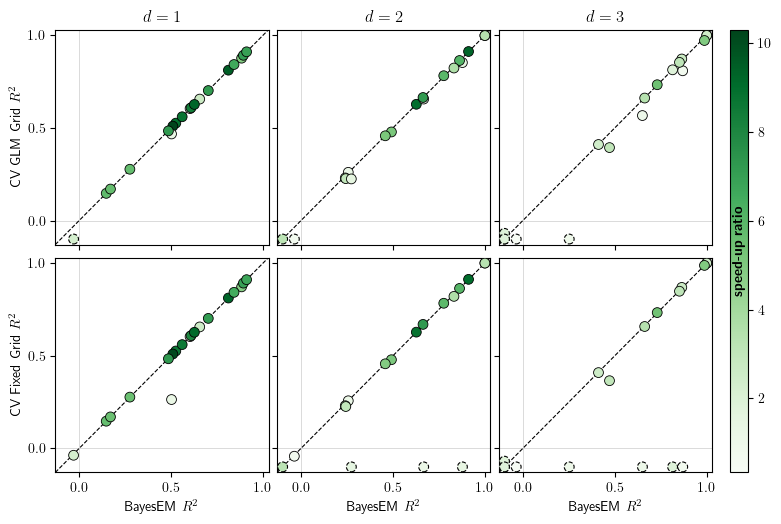

In [19]:
su_all = [np.nanmean(e.fitting_time_[:, i, 0, cv]) / np.nanmean(e.fitting_time_[:, i, 0, 0])
          for e in [exp_full, exp_full_d2, exp_full_d3] for cv in [1, 2] for i in range(len(e.problems))]
norm = mcolors.Normalize(vmin=min(su_all), vmax=max(su_all))

fig, axes = grid_with_colourbar(2, 3, norm, plt.cm.Greens,
                                y_labels=['CV GLM Grid $R^2$', 'CV Fixed Grid $R^2$'],
                                col_titles=['$d=1$', '$d=2$', '$d=3$'],
                                x_labels='BayesEM $R^2$', cbar_label=r'\textbf{speed-up ratio}')


for col, e in enumerate([exp_full, exp_full_d2, exp_full_d3]):
    for row, cv in enumerate([2, 1]):
        scatter_clipped(np.nanmean(e.prediction_r2_[:, :, 0, 0], axis=0),
                        np.nanmean(e.prediction_r2_[:, :, 0, cv], axis=0),
                        np.nanmean(e.fitting_time_[:, :, 0, cv], axis=0)
                        / np.nanmean(e.fitting_time_[:, :, 0, 0], axis=0),
                        norm, plt.cm.Greens, ax=axes[row, col])


In [20]:
problems_large = [
    EmpiricalDataProblem('twitter',   'V78',       zero_variance_filter=True),
    EmpiricalDataProblem('tomshw',    'V97',       zero_variance_filter=True),
    EmpiricalDataProblem('blog',      'V281',      zero_variance_filter=True),
    EmpiricalDataProblem('ct_slices', 'reference', zero_variance_filter=True),
]

In [21]:
exp_large = Experiment(
    problems_large, list(estimators_full.values()),
    reps=30, ns=[[NEURIPS2023_TRAIN_SIZES[p.dataset]] for p in problems_large],
    seed=123,
    est_names=list(estimators_full.keys())).run()
print()

twitter ................................................................................

/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:341: UserWarning: FittingTime: only one computation stored; reliability unknown. Re-run with force_recompute=True to improve estimate.
  warnings.warn(msg)


..........
tomshw ..........................................................................................
blog ..........................................................................................
ct_slices ..........................................................................................



In [22]:
rows_large = []
for i, problem in enumerate(exp_large.problems):
    em_time = stat_mean(exp_large, 'fitting_time', 'EM', i)
    cv_time = (stat_mean(exp_large, 'fitting_time', 'CV_glm', i)
               + stat_mean(exp_large, 'fitting_time', 'CV_fix', i)) / 2
    row = {'dataset': problem.dataset, 'target': problem.target}
    row.update({est: stat_mean(exp_large, 'prediction_r2', est, i) for est in exp_large.est_names})
    row['Speed Up Ratio'] = cv_time / em_time
    row['p']              = stat_mean(exp_large, 'number_of_features', 'EM', i)
    row['n_train']        = int(exp_large.ns[i, 0])
    row['n:p']            = int(exp_large.ns[i, 0]) / stat_mean(exp_large, 'number_of_features', 'EM', i)
    rows_large.append(row)
pd.DataFrame(rows_large).sort_values('n_train', ascending=False).round(2)

,dataset,target,EM,CV_fix,CV_glm,Speed Up Ratio,p,n_train,n:p
0,twitter,V78,0.93,0.93,0.93,4.57,77.00,408275,5302.27
3,ct_slices,reference,0.86,0.86,0.86,3.53,379.53,37450,98.67
2,blog,V281,0.36,0.36,0.36,3.71,276.00,36677,132.89
1,tomshw,V97,0.96,0.96,0.96,3.70,96.00,19725,205.47


In [23]:
problems_large_d2 = [
    EmpiricalDataProblem('twitter',   'V78',       x_transforms=(PolynomialExpansion(2),), zero_variance_filter=True),
    EmpiricalDataProblem('tomshw',    'V97',       x_transforms=(PolynomialExpansion(2),), zero_variance_filter=True),
    EmpiricalDataProblem('blog',      'V281',      x_transforms=(PolynomialExpansion(2),), zero_variance_filter=True),
    EmpiricalDataProblem('ct_slices', 'reference', x_transforms=(PolynomialExpansion(2),), zero_variance_filter=True),
]

In [24]:
exp_large_d2 = Experiment(
    problems_large_d2, list(estimators_full.values()),
    reps=30, ns=[[NEURIPS2023_TRAIN_SIZES[p.dataset]] for p in problems_large_d2],
    seed=123,
    est_names=list(estimators_full.keys())).run()
print()

twitter ........................................................................................

/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:341: UserWarning: FittingTime: only one computation stored; reliability unknown. Re-run with force_recompute=True to improve estimate.
  warnings.warn(msg)


..
tomshw ..........................................................................................
blog ..........................................................................................
ct_slices ..........................................................................................



In [25]:
rows_large_d2 = []
for i, problem in enumerate(exp_large_d2.problems):
    em_time = stat_mean(exp_large_d2, 'fitting_time', 'EM', i)
    cv_time = (stat_mean(exp_large_d2, 'fitting_time', 'CV_glm', i)
               + stat_mean(exp_large_d2, 'fitting_time', 'CV_fix', i)) / 2
    row = {'dataset': problem.dataset, 'target': problem.target}
    row.update({est: stat_mean(exp_large_d2, 'prediction_r2', est, i) for est in exp_large_d2.est_names})
    row['Speed Up Ratio'] = cv_time / em_time
    row['p']              = stat_mean(exp_large_d2, 'number_of_features', 'EM', i)
    row['n_train']        = int(exp_large_d2.ns[i, 0])
    row['n:p']            = int(exp_large_d2.ns[i, 0]) / stat_mean(exp_large_d2, 'number_of_features', 'EM', i)
    rows_large_d2.append(row)
pd.DataFrame(rows_large_d2).sort_values('n_train', ascending=False).round(2)

,dataset,target,EM,CV_fix,CV_glm,Speed Up Ratio,p,n_train,n:p
0,twitter,V78,0.91,0.91,0.91,4.83,86.00,408275,4747.38
3,ct_slices,reference,0.92,0.92,0.92,2.90,929.43,37450,40.29
2,blog,V281,-0.00,0.10,0.01,2.84,886.67,36677,41.37
1,tomshw,V97,0.92,0.96,0.96,2.02,1775.00,19725,11.11


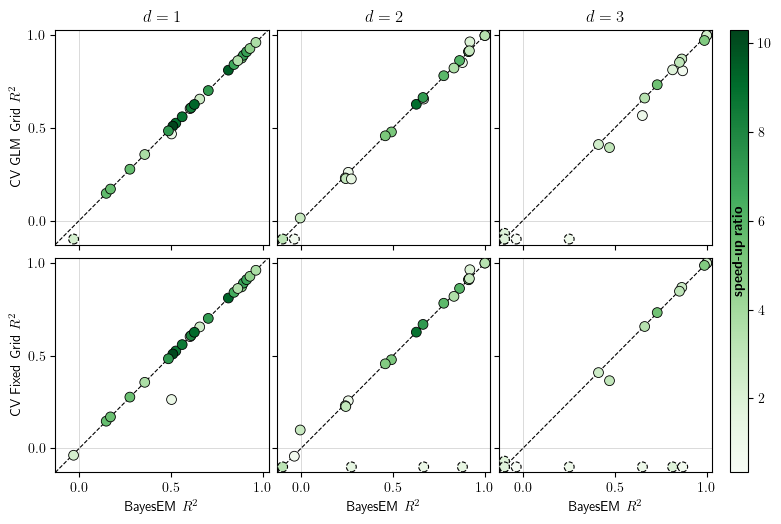

In [26]:
col_exps = [[exp_full, exp_large], [exp_full_d2, exp_large_d2], [exp_full_d3]]

su_all = [np.nanmean(e.fitting_time_[:, i, 0, cv]) / np.nanmean(e.fitting_time_[:, i, 0, 0])
          for exps in col_exps for e in exps for cv in [1, 2] for i in range(len(e.problems))]
norm = mcolors.Normalize(vmin=min(su_all), vmax=max(su_all))

fig, axes = grid_with_colourbar(2, 3, norm, plt.cm.Greens,
                                y_labels=['CV GLM Grid $R^2$', 'CV Fixed Grid $R^2$'],
                                col_titles=['$d=1$', '$d=2$', '$d=3$'],
                                x_labels='BayesEM $R^2$', cbar_label=r'\textbf{speed-up ratio}')


for col, exps in enumerate(col_exps):
    for row, cv in enumerate([2, 1]):
        scatter_clipped(
            np.concatenate([np.nanmean(e.prediction_r2_[:, :, 0, 0], axis=0) for e in exps]),
            np.concatenate([np.nanmean(e.prediction_r2_[:, :, 0, cv], axis=0) for e in exps]),
            np.concatenate([np.nanmean(e.fitting_time_[:, :, 0, cv], axis=0)
                            / np.nanmean(e.fitting_time_[:, :, 0, 0], axis=0) for e in exps]),
            norm, plt.cm.Greens, ax=axes[row, col])

fig.savefig('../output/realdata_r2_by_degree.pdf', bbox_inches='tight')
